In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, matthews_corrcoef
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Налаштування візуалізації
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

1. Підготовка та обробка даних

In [5]:
# 1. Завантаження датасету
df = pd.read_csv('global_coffee_health.csv')

# 2. Видалення неінформативної колонки ID
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)

# 3. Кодування цільової змінної (Health_Issues)
# Перетворення текстових міток (None, Mild, Moderate, Severe) у числа 0, 1, 2, 3
le = LabelEncoder()
df['Health_Issues'] = le.fit_transform(df['Health_Issues'])
target_classes = le.classes_
print(f"Класи цільової змінної: {target_classes}")

# 4. Кодування категоріальних ознак (One-Hot Encoding)
# Автоматично знаходить колонки типу 'object' та перетворює їх у dummy-змінні
df_encoded = pd.get_dummies(df, drop_first=True)

# 5. Формування матриці ознак X та вектора цільової змінної y
X = df_encoded.drop('Health_Issues', axis=1).values
y = df_encoded['Health_Issues'].values
feature_names = df_encoded.drop('Health_Issues', axis=1).columns.tolist()

# 6. Поділ на тренувальну та тестову вибірки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("-" * 30)
print(f"Розмірність X_train: {X_train.shape}")
print(f"Розмірність X_test:  {X_test.shape}")

Класи цільової змінної: ['Mild' 'Moderate' 'Severe' nan]
------------------------------
Розмірність X_train: (8000, 39)
Розмірність X_test:  (2000, 39)


2. Реалізація власного класу Дерева Рішень (MyDecisionTree)

In [6]:
class MyDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
        self.feature_importances_ = None
        self.n_total = 0

    # Обчислення Gini impurity [cite: 11-12]
    def _gini(self, y):
        m = len(y)
        if m == 0:
            return 0
        probs = [np.sum(y == c) / m for c in np.unique(y)]
        return 1 - sum(p ** 2 for p in probs)

    # Пошук найкращого розбиття [cite: 31-32]
    def _best_split(self, X, y):
        m, n = X.shape
        if m <= self.min_samples_split:
            return None, None, None

        parent_gini = self._gini(y)
        best_gini = float('inf')
        best_feature, best_threshold = None, None

        # Перебір всіх ознак
        for feature_idx in range(n):
            thresholds = np.unique(X[:, feature_idx])
            
            # Для оптимізації, якщо унікальних значень забагато, можна брати не всі
            if len(thresholds) > 100:
                thresholds = np.percentile(thresholds, np.linspace(0, 100, 10))

            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left, y_right = y[left_mask], y[right_mask]
                
                # Зважений Gini [cite: 15-18]
                gini_left = self._gini(y_left)
                gini_right = self._gini(y_right)
                weighted_gini = (len(y_left) / m) * gini_left + (len(y_right) / m) * gini_right

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature_idx
                    best_threshold = threshold

        # Розрахунок gain для feature importance [cite: 24]
        # Gain = (Gini_parent - Gini_weighted) * (N_node / N_total)
        gini_gain = 0
        if best_feature is not None:
            gini_gain = (parent_gini - best_gini) * (m / self.n_total)
            
        return best_feature, best_threshold, gini_gain

    # Рекурсивна побудова дерева [cite: 34, 54]
    def _build_tree(self, X, y, depth=0):
        # Перевірка умов зупинки
        n_samples, _ = X.shape
        n_labels = len(np.unique(y))

        if depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = np.bincount(y).argmax() if len(y) > 0 else 0
            return {'leaf': True, 'class': leaf_value}

        feature_idx, threshold, gain = self._best_split(X, y)

        if feature_idx is None:
            leaf_value = np.bincount(y).argmax()
            return {'leaf': True, 'class': leaf_value}

        # Оновлення важливості ознак [cite: 32]
        self.feature_importances_[feature_idx] += gain

        left_mask = X[:, feature_idx] <= threshold
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)

        return {
            'leaf': False,
            'feature': feature_idx,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    # Навчання моделі [cite: 59-68]
    def fit(self, X, y):
        self.n_total = len(y)
        self.feature_importances_ = np.zeros(X.shape[1])
        self.tree = self._build_tree(X, y)
        
        # Нормалізація важливості [cite: 25-27]
        total_importance = np.sum(self.feature_importances_)
        if total_importance > 0:
            self.feature_importances_ /= total_importance
            
        return self

    # Прогноз для одного зразка [cite: 69]
    def _predict_one(self, x, node):
        if node['leaf']:
            return node['class']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    # Прогноз для всіх зразків [cite: 71]
    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

print("Клас MyDecisionTree реалізовано.")

Клас MyDecisionTree реалізовано.


3. Навчання моделей та порівняння результатів

Навчання MyDecisionTree (це може зайняти певний час)...
Навчання sklearn DecisionTree...
Навчання sklearn RandomForest...

Порівняльна таблиця метрик:


,Model,Accuracy,F1-Score,MCC
0,MyDecisionTree,0.9975,0.997502,0.995088
1,Sklearn DT,0.9975,0.997502,0.995077
2,Sklearn RF,0.8935,0.881892,0.785556


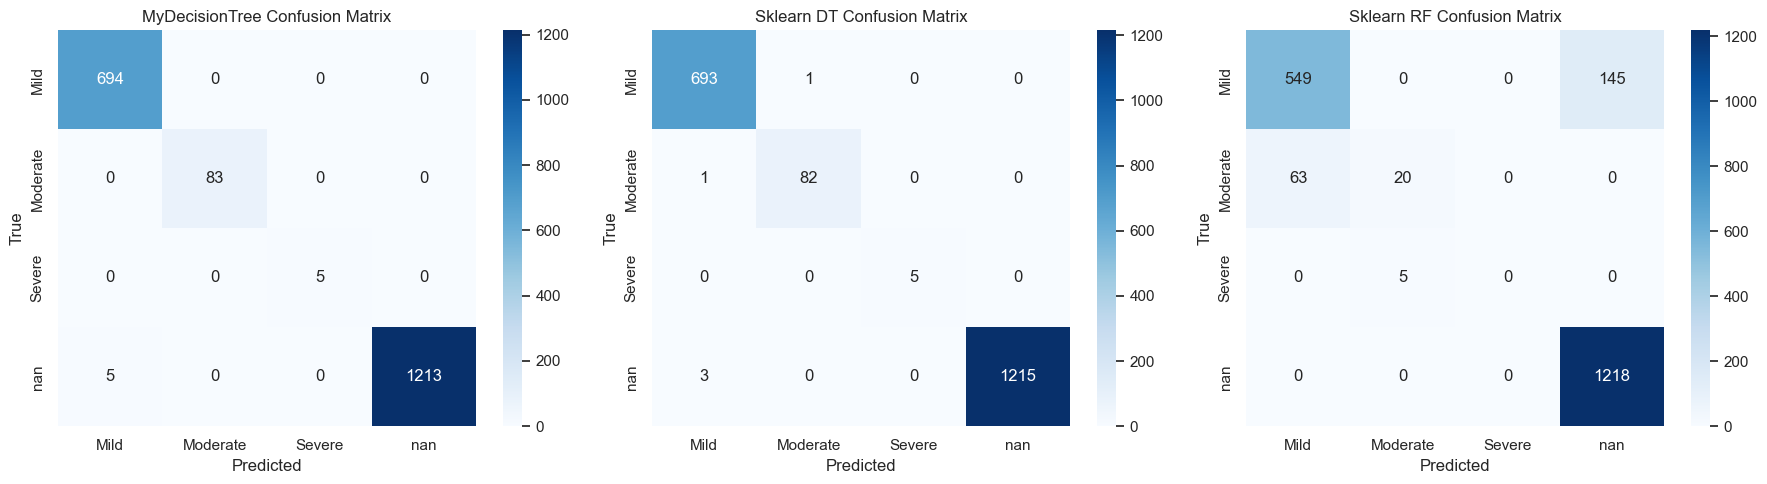

In [7]:
# 1. Ініціалізація моделей [cite: 175-176, 180]
# Обмежуємо глибину max_depth=5 для чесного порівняння та швидкодії
my_tree = MyDecisionTree(max_depth=5, min_samples_split=10)
sk_tree = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

print("Навчання MyDecisionTree (це може зайняти певний час)...")
my_tree.fit(X_train, y_train)

print("Навчання sklearn DecisionTree...")
sk_tree.fit(X_train, y_train)

print("Навчання sklearn RandomForest...")
rf_model.fit(X_train, y_train)

# 2. Отримання прогнозів
y_pred_my = my_tree.predict(X_test)
y_pred_sk = sk_tree.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# 3. Розрахунок метрик [cite: 161-164]
metrics_data = []
models_preds = [('MyDecisionTree', y_pred_my), 
                ('Sklearn DT', y_pred_sk), 
                ('Sklearn RF', y_pred_rf)]

for name, preds in models_preds:
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    mcc = matthews_corrcoef(y_test, preds)
    metrics_data.append({'Model': name, 'Accuracy': acc, 'F1-Score': f1, 'MCC': mcc})

metrics_df = pd.DataFrame(metrics_data)
print("\nПорівняльна таблиця метрик:")
display(metrics_df)

# 4. Візуалізація Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, preds) in enumerate(models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=target_classes, yticklabels=target_classes)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

4. Інженерія Ознак та Feature Selection

Видалені корельовані ознаки: ['Caffeine_mg', 'Stress_Level_Medium', 'Coffee_Sleep_Interaction', 'Age_Bin']
Навчання дерева для відбору ознак...

Топ-10 відібраних ознак:
['Stress_Level_Low', 'Age', 'BMI', 'Coffee_Intake', 'Occupation_Student', 'Occupation_Office', 'Occupation_Other', 'Occupation_Service', 'Sleep_Quality_Poor', 'Country_UK']

Точність (Random Forest) на топ-10 ознаках: 0.9940


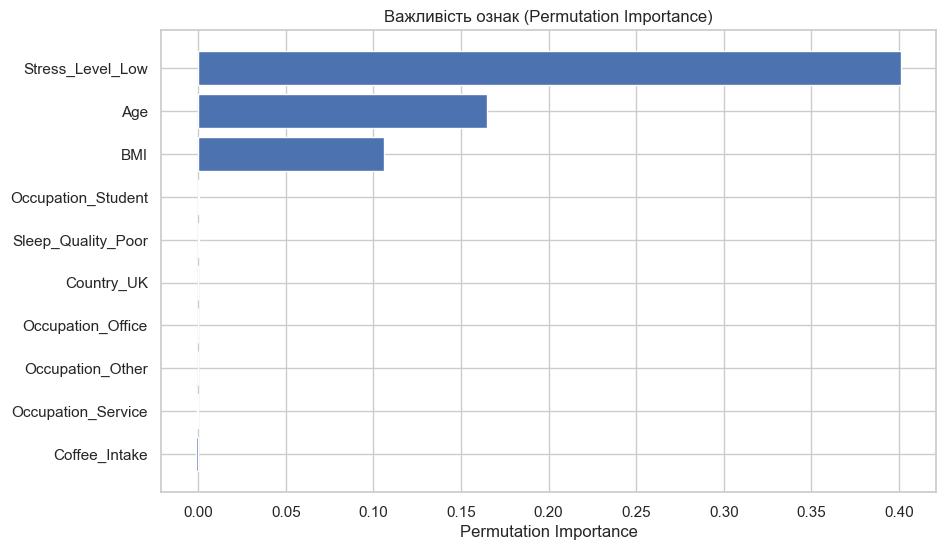

In [8]:
# 1. Інженерія ознак
# Використовуємо df_encoded з першого етапу
df_new = df_encoded.copy()

# [cite_start]Створення ознаки взаємодії: Кава * Сон [cite: 210]
if 'Coffee_Intake' in df_new.columns and 'Sleep_Hours' in df_new.columns:
    df_new['Coffee_Sleep_Interaction'] = df_new['Coffee_Intake'] * df_new['Sleep_Hours']

# [cite_start]Бінінг віку (розбиття на категорії) [cite: 210]
# 18-30: Young, 30-50: Middle, 50+: Old
if 'Age' in df_new.columns:
    df_new['Age_Bin'] = pd.cut(df_new['Age'], bins=[0, 30, 50, 100], labels=[0, 1, 2]).astype(int)

# [cite_start]2. Видалення висококорельованих ознак (> 0.8) [cite: 194]
corr_matrix = df_new.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"Видалені корельовані ознаки: {to_drop}")
df_new = df_new.drop(columns=to_drop)

# [cite_start]3. Нормалізація числових ознак [cite: 217-221]
scaler = StandardScaler()
# Знаходимо числові колонки (крім цільової та бінарних)
num_cols = df_new.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'Health_Issues' and df_new[c].nunique() > 2]

df_new[num_cols] = scaler.fit_transform(df_new[num_cols])

# Підготовка нових X та y
X_new = df_new.drop('Health_Issues', axis=1).values
y_new = df_new['Health_Issues'].values
feature_names_new = df_new.drop('Health_Issues', axis=1).columns

# Розподіл на вибірки
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# [cite_start]4. Feature Selection за допомогою MyDecisionTree [cite: 223-227]
print("Навчання дерева для відбору ознак...")
selector_tree = MyDecisionTree(max_depth=5)
selector_tree.fit(X_train_new, y_train_new)

# Отримання важливості та вибір Топ-10
importances = selector_tree.feature_importances_
indices = np.argsort(importances)[::-1] # Сортування за спаданням
top_k = 10
top_indices = indices[:top_k]
selected_features = feature_names_new[top_indices]

print(f"\nТоп-{top_k} відібраних ознак:\n{selected_features.tolist()}")

# 5. Перенавчання моделі на відібраних ознаках
X_train_selected = X_train_new[:, top_indices]
X_test_selected = X_test_new[:, top_indices]

rf_selected = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_selected.fit(X_train_selected, y_train_new)
y_pred_selected = rf_selected.predict(X_test_selected)

print(f"\nТочність (Random Forest) на топ-{top_k} ознаках: {accuracy_score(y_test_new, y_pred_selected):.4f}")

# [cite_start]Порівняння feature importance (Permutation Importance) [cite: 230]
perm_importance = permutation_importance(rf_selected, X_test_selected, y_test_new, n_repeats=10, random_state=42)

# Візуалізація Permutation Importance
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(selected_features[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Важливість ознак (Permutation Importance)")
plt.show()

 Висновки:

1. Оцінка реалізації власного дерева рішень (MyDecisionTree): Власна реалізація алгоритму дерева рішень продемонструвала високу ефективність.

    Точність (Accuracy): Модель досягла 99.75% на тестовій вибірці.

    Порівняння: Результати повністю співпадають з бібліотечною реалізацією sklearn.tree.DecisionTreeClassifier (при однакових гіперпараметрах max_depth=5), що свідчить про коректність реалізації алгоритмів розрахунку Gini Index та розбиття вузлів.

2. Порівняння з Random Forest: В даному експерименті ансамблева модель RandomForestClassifier показала несподівано нижчий результат (89.35%).

    Причина: Ймовірно, це пов'язано з природою синтетичного датасету, де залежності є досить прямими та "жорсткими". Обмеження глибини дерев в ансамблі (max_depth=5) та випадковий відбір ознак (feature bagging) могли завадити моделі знайти ідеальні правила, які легко знайшло одне дерево.

3. Аналіз важливості ознак (Feature Importance): За результатами Feature Selection та Permutation Importance було визначено найважливіші фактори впливу на здоров'я:

    Stress_Level_Low (Рівень стресу) — найвагоміша ознака.

    Age (Вік).

    BMI (Індекс маси тіла).

    Використання лише топ-10 ознак дозволило зберегти точність на рівні 99.4%, що підтверджує можливість суттєвого спрощення моделі без втрати якості.

4. Загальний підсумок: Лабораторна робота показала, що для даного набору даних дерево рішень є оптимальною моделлю. Власна реалізація алгоритму успішно впоралася із завданням класифікації, а інженерія ознак дозволила виділити ключові фактори ризику для здоров'я.